# ЛР №7. Построение автокодировщика

**Выполнил:** Яковенко Максим Михайлович, группа МИК11 (Т26ИИКТ-МИК11)

**Вариант 2:** N = (номер набора − 1) · 6 + номер фактора = (1 − 1) · 6 + 2.

| | |
| --- | --- |
| Набор сцен | 1 — «диск» (`disc`): янтарный диск на градиентном фоне, три фактора сцены (центр по x и y, радиус) |
| Фактор | 2 — размер латентного вектора `d = 8 → 32` (`latent_8_to_32`) |
| Режим A | свёрточный автокодировщик, `d = 8`, MSE, чистый вход, 4096 сцен, 20 эпох |
| Режим B | то же, `d = 32` |
| Серия seed | 101…105; данные порождаются кодом с seed 7 |
| Библиотека | `lab07_lib.py` из приложения А указаний (8679 байт, SHA-256 `d84b83a8…`) |

**Репозиторий работы:** https://github.com/ykvnkm/ai-in-creative-industries/tree/main/LR07

Библиотека сама выбирает устройство (`cuda`, если есть, иначе `cpu`), код указаний не
менялся. Обучение на CPU предусмотрено только как запасной путь.

## 1. Цель, задача и критерии успеха

**Цель.** Построить свёрточный автокодировщик на синтетических сценах и
экспериментом выяснить, окупается ли рост узкого места с 8 до 32 чисел: что
происходит с качеством реконструкции на отложенной выборке, разрывом train − test,
числом параметров и временем обучения.

**Что нужно получить** (раздел 3 указаний): (а) таблицу метрик по серии seed;
(б) эталон «средняя картинка»; (в) лист сравнения `comparison.png` для seed 101;
(г) классификацию отклика по допуску, записанному до запуска; (д) вывод и паспорт.

**Критерий успеха.** Гипотеза и допуск записаны до запуска; изменён ровно один фактор;
пять seed; PSNR сопоставлен с эталоном; оценка на тестовой выборке; вывод отделяет
статистическую значимость от практической пользы и наблюдение от объяснения.

**Соответствие плану (раздел 5 указаний):**

| Шаг плана | Раздел блокнота |
| --- | --- |
| 1. среда | 2, 3 |
| 2. гипотеза и допуск | 4 |
| 3. режимы A и B | 4 |
| 4. `variant_summary(2)` | 7 |
| 5. эталон «средняя картинка» | 6 |
| 6. `comparison.png` | 10 |
| 7. классификация по допуску | 8 |
| 8. диагностика по `d` | 9 |
| 9. паспорт и отчёт | 14–16, отчёт |

Дополнительно: проверка формы и положения диска по всей тестовой выборке (требование
варианта, раздел 11) и сверка с прогоном преподавателя на Colab (раздел 12).

**Оценка времени.** Всего 30 обучений по 20 эпох: 11 в серии (`variant_summary`,
включая прогрев), 18 в развёртке по `d` (6 значений × 3 seed), 1 повторное для проверки
детерминизма. Лист сравнения строится из моделей развёртки без переобучения. На GPU
одно обучение занимает около 2 с (по журналу указаний для T4), то есть всего
**1–3 мин** вместе с построением данных. Если GPU недоступен и библиотека выберет CPU,
одно обучение займёт от десятков секунд до нескольких минут, а весь блокнот — от
десятков минут до нескольких часов. Точное время на одно обучение печатается после
серии, вместе с прогнозом на оставшиеся шаги.

## 2. Подготовка среды

Ячейка ниже:

1. создаёт рабочую папку `LR07` в текущем каталоге и переходит в неё;
   все результаты пишутся по абсолютному пути в `artifacts/`;
2. проверяет пакеты `numpy`, `Pillow`, `torch` и доустанавливает недостающие через
   `pip`; `torch` ставится стандартной сборкой с поддержкой CUDA, чтобы использовать
   GPU;
3. на случай запасного пути (обучение на CPU) ограничивает число потоков `torch`
   числом ядер, реально выделенных контейнеру (`cgroup`): если потоков больше, чем
   ядер, обучение на CPU резко замедляется; на GPU эта настройка почти не влияет;
4. печатает версии, имя GPU и версию CUDA для паспорта эксперимента; если GPU не
   найден, об этом выводится предупреждение.

In [1]:
# Шаг 1 плана: рабочая папка, пакеты, сведения о среде.
import os, sys, platform, subprocess, importlib, time
from pathlib import Path

T_START = time.perf_counter()
WORK = Path.cwd() / "LR07"
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
ART = WORK / "artifacts"
ART.mkdir(exist_ok=True)


def ensure(module, pip_args):
    """Импортирует модуль; если его нет — ставит через pip в окружение ядра."""
    try:
        return importlib.import_module(module)
    except ImportError:
        print(f"{module}: не найден, выполняю pip install {' '.join(pip_args)}")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pip_args], check=True)
        importlib.invalidate_caches()
        return importlib.import_module(module)


np = ensure("numpy", ["numpy"])
PIL = ensure("PIL", ["Pillow"])
torch = ensure("torch", ["torch"])   # стандартная сборка с поддержкой CUDA


def read(path):
    try:
        return Path(path).read_text()
    except OSError:
        return ""


def cgroup_cpus():
    """Сколько ядер выделено контейнеру по квоте cgroup (v2, затем v1); None — квоты нет."""
    q = read("/sys/fs/cgroup/cpu.max").split()
    if len(q) == 2 and q[0] != "max":
        return float(q[0]) / float(q[1])
    q, p = read("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").strip(), read("/sys/fs/cgroup/cpu/cpu.cfs_period_us").strip()
    if q and p and int(q) > 0:
        return int(q) / int(p)
    return None


def cpu_model():
    for line in read("/proc/cpuinfo").splitlines():
        if line.startswith("model name"):
            return line.split(":", 1)[1].strip()
    return platform.processor() or platform.machine()


def ram_gb():
    for line in read("/proc/meminfo").splitlines():
        if line.startswith("MemTotal"):
            return round(int(line.split()[1]) / 2**20, 1)
    return None


affinity = len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else os.cpu_count()
quota = cgroup_cpus()
threads = max(1, min(torch.get_num_threads(), affinity, int(quota) if quota else affinity))
torch.set_num_threads(threads)

mem_limit = read("/sys/fs/cgroup/memory.max").strip()
ENV = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "numpy": np.__version__,
    "Pillow": PIL.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "cuda_version": torch.version.cuda,
    "cpu_model": cpu_model(),
    "os_cpu_count": os.cpu_count(),
    "cpu_affinity": affinity,
    "cgroup_cpu_quota": quota,
    "torch_threads": torch.get_num_threads(),
    "ram_total_gb": ram_gb(),
    "cgroup_memory_max": mem_limit or None,
}
print("рабочая папка:", WORK)
for key, value in ENV.items():
    print(f"{key:18s} {value}")
if not torch.cuda.is_available():
    print("ВНИМАНИЕ: GPU не найден, обучение пойдёт на CPU (запасной путь, намного дольше)")

рабочая папка: /content/LR07
python             3.13.15
platform           Linux-6.6.122+-x86_64-with-glibc2.39
torch              2.11.0+cu130
numpy              2.1.3
Pillow             11.3.0
cuda_available     True
gpu                Tesla T4
cuda_version       13.0
cpu_model          Intel(R) Xeon(R) CPU @ 2.00GHz
os_cpu_count       2
cpu_affinity       2
cgroup_cpu_quota   None
torch_threads      1
ram_total_gb       12.7
cgroup_memory_max  max


## 3. Библиотека `lab07_lib.py`

Как требуют указания (раздел 4, приложение А), библиотека записывается в блокнот
ячейкой `%%writefile`. Текст ячейки после первой строки побайтно совпадает с файлом
`assignment/src/lab07_lib.py` из репозитория. Что в библиотеке:

* `render`, `dataset` — порождение сцен 3 × 32 × 32 по вектору факторов; выборки
  4096 + 1024 сцены строятся с seed 7 и одинаковы во всех запусках;
* `ConvAE` — кодировщик (три свёртки с шагом 2: 32 → 16 → 8 → 4, затем `Linear(1024, d)`
  в латентный вектор) и декодировщик (`Linear(d, 1024)` и три транспонированные
  свёртки 4 → 8 → 16 → 32, на выходе сигмоида);
* `train` — Adam, шаг 2·10⁻³, пакет 128, MSE; `run` — одно обучение и метрики
  (PSNR на тесте, разрыв train − test, число параметров, время);
* `settings` — режимы A и B фактора; `variant_summary` — серия seed 101…105 и строки
  таблицы (A, s, B, Δ, |Δ|/s, признак |Δ| > 2s).

In [2]:
%%writefile lab07_lib.py
# ЛР 7. Построение автокодировщика. Библиотека учебных функций.
# Проверено 19.09.2026: Google Colab, GPU T4, Python 3.13, torch 2.11.0+cu128. Внешние данные не нужны: сцены порождаются кодом.
import time
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N = 32                      # сторона изображения
SEEDS = range(101, 106)     # серия seed обучения
KINDS = ["disc", "disc_rect", "disc_noise", "disc_color", "two_discs"]   # пять контекстов (наборов данных)
N_FACTORS = {"disc": 3, "disc_rect": 4, "disc_noise": 3, "disc_color": 4, "two_discs": 4}
AMBER, GREEN, PINK = (1.0, 0.76, 0.29), (0.24, 0.86, 0.60), (0.95, 0.35, 0.55)
_YY, _XX = np.mgrid[0:N, 0:N] / (N - 1)


def _disc(img, cx, cy, r, color):
    m = (_XX - cx) ** 2 + (_YY - cy) ** 2 <= r * r
    for k in range(3):
        img[k][m] = color[k]


def _hue(h):
    """Простой цвет по параметру 0..1 (три сдвинутые косинусоиды)."""
    return tuple(0.5 + 0.5 * np.cos(2 * np.pi * (h + s)) for s in (0.0, 1 / 3, 2 / 3))


def render(kind, f):
    """Сцена 3×N×N по вектору факторов f из отрезка [0, 1]: положения и размеры объектов задают изображение однозначно."""
    img = np.zeros((3, N, N), dtype=np.float32)
    img[:] = (0.10 + 0.25 * (_XX + _YY) / 2)[None]
    if kind in ("disc", "disc_noise"):
        _disc(img, 0.25 + 0.5 * f[0], 0.25 + 0.5 * f[1], 0.12 + 0.10 * f[2], AMBER)
    elif kind == "disc_rect":
        _disc(img, 0.25 + 0.5 * f[0], 0.30 + 0.25 * f[1], 0.12 + 0.08 * f[2], AMBER)
        x0 = int((0.05 + 0.55 * f[3]) * N); img[:, int(0.72 * N):int(0.92 * N), x0:x0 + int(0.3 * N)] = np.array(GREEN)[:, None, None]
    elif kind == "disc_color":
        _disc(img, 0.25 + 0.5 * f[0], 0.25 + 0.5 * f[1], 0.12 + 0.10 * f[2], _hue(f[3]))
    elif kind == "two_discs":
        _disc(img, 0.15 + 0.3 * f[0], 0.15 + 0.7 * f[1], 0.12, AMBER)
        _disc(img, 0.55 + 0.3 * f[2], 0.15 + 0.7 * f[3], 0.12, PINK)
    else:
        raise ValueError(kind)
    return img


_CACHE = {}


def dataset(kind, n_train=4096, n_test=1024):
    """Обучающая и тестовая выборки (тензоры на устройстве) и факторы. Данные одинаковы для всех запусков (seed 7)."""
    if kind not in _CACHE:
        rng = np.random.default_rng(7)
        f = rng.random((n_train + n_test, N_FACTORS[kind]))
        x = np.stack([render(kind, fi) for fi in f])
        if kind == "disc_noise":
            x = np.clip(x + 0.05 * rng.standard_normal(x.shape).astype(np.float32), 0, 1)
        X = torch.tensor(x, dtype=torch.float32, device=DEVICE); F = torch.tensor(f, dtype=torch.float32, device=DEVICE)
        _CACHE[kind] = (X[:n_train], X[n_train:], F[:n_train], F[n_train:])
    return _CACHE[kind]


class ConvAE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv2d(3, 16, 4, 2, 1), nn.ReLU(), nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),
                                 nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(), nn.Flatten(), nn.Linear(64 * 16, d))
        self.dec_fc = nn.Sequential(nn.Linear(d, 64 * 16), nn.ReLU())
        self.dec = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(), nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),
                                 nn.ConvTranspose2d(16, 3, 4, 2, 1), nn.Sigmoid())

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(self.dec_fc(z).view(-1, 64, 4, 4))

    def forward(self, x):
        return self.decode(self.encode(x))


class DenseAE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(3 * N * N, 256), nn.ReLU(), nn.Linear(256, d))
        self.dec = nn.Sequential(nn.Linear(d, 256), nn.ReLU(), nn.Linear(256, 3 * N * N), nn.Sigmoid())

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z).view(-1, 3, N, N)

    def forward(self, x):
        return self.decode(self.encode(x))


def build(arch, d):
    return (ConvAE if arch == "conv" else DenseAE)(d).to(DEVICE)


def n_params(model):
    return sum(p.numel() for p in model.parameters())


def psnr_images(x, y):
    """Средний по изображениям PSNR, дБ (значения 0..1)."""
    mse = ((x - y) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return float((10 * torch.log10(1.0 / mse)).mean())


def train(model, Xtr, epochs=20, lr=2e-3, loss="mse", noise=0.0, seed=0, batch=128):
    """Обучение с Adam. loss: 'mse' или 'l1'. noise > 0: вход зашумляется (шумоподавляющий автокодировщик), цель — чистое изображение."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, generator=g).to(DEVICE)
        for i in range(0, n, batch):
            x = Xtr[perm[i:i + batch]]
            xin = (x + noise * torch.randn(x.shape, generator=g).to(DEVICE)).clamp(0, 1) if noise > 0 else x
            out = model(xin)
            l = ((out - x) ** 2).mean() if loss == "mse" else (out - x).abs().mean()
            opt.zero_grad(); l.backward(); opt.step()
    return model


@torch.no_grad()
def reconstruct(model, X, eval_noise=0.0, seed=1234):
    model.eval()
    if eval_noise > 0:
        g = torch.Generator(device="cpu").manual_seed(seed)
        X = (X + eval_noise * torch.randn(X.shape, generator=g).to(DEVICE)).clamp(0, 1)
    return model(X)


# Шесть факторов: изменение базового режима A (свёрточный автокодировщик, d = 8, MSE, чистые данные, 4096 примеров).
FACTORS = ["latent_8_to_2", "latent_8_to_32", "arch_conv_to_dense", "loss_mse_to_l1", "input_clean_to_denoising", "train_4096_to_512"]
BASE = dict(arch="conv", d=8, loss="mse", noise=0.0, eval_noise=0.0, n_train=4096, epochs=20)


def settings(factor):
    a, b = dict(BASE), dict(BASE)
    if factor == "latent_8_to_2":
        b["d"] = 2
    elif factor == "latent_8_to_32":
        b["d"] = 32
    elif factor == "arch_conv_to_dense":
        b["arch"] = "dense"
    elif factor == "loss_mse_to_l1":
        b["loss"] = "l1"
    elif factor == "input_clean_to_denoising":
        a["eval_noise"] = b["eval_noise"] = 0.2; b["noise"] = 0.2
    elif factor == "train_4096_to_512":
        b["n_train"] = 512; b["epochs"] = 160   # 512 / 128 * 160 = 640 шагов, как 4096 / 128 * 20: число обновлений весов сохранено
    else:
        raise ValueError(factor)
    return a, b


def run(kind, cfg, seed):
    """Одно обучение: метрики на тестовой выборке."""
    Xtr, Xte, _, _ = dataset(kind)
    Xtr = Xtr[:cfg["n_train"]]
    torch.manual_seed(seed)
    t0 = time.perf_counter()
    model = train(build(cfg["arch"], cfg["d"]), Xtr, cfg["epochs"], loss=cfg["loss"], noise=cfg["noise"], seed=seed)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    p_te = psnr_images(reconstruct(model, Xte, cfg["eval_noise"]), Xte)
    p_tr = psnr_images(reconstruct(model, Xtr[:1024], cfg["eval_noise"]), Xtr[:1024])
    return dict(psnr=p_te, gap=p_tr - p_te, params=n_params(model) / 1000, seconds=dt), model


def variant_summary(n, seeds=SEEDS):
    """Вариант n = 1..30: набор данных c = (n-1)//6, фактор k = (n-1)%6. Для каждой метрики: A, s, B, разность, |d|/s, признак |d| > 2s."""
    c, k = (n - 1) // 6, (n - 1) % 6
    a_cfg, b_cfg = settings(FACTORS[k])
    A = {m: [] for m in ("psnr", "gap", "params", "seconds")}
    B = {m: [] for m in A}
    run(KINDS[c], a_cfg, 0)  # прогрев
    for s in seeds:
        ma, _ = run(KINDS[c], a_cfg, s)
        mb, _ = run(KINDS[c], b_cfg, s)
        for m in A:
            A[m].append(ma[m]); B[m].append(mb[m])
    rows = []
    for m in A:
        d = np.mean(B[m]) - np.mean(A[m]); sa = np.std(A[m], ddof=1)
        rows.append((m, float(np.mean(A[m])), float(sa), float(np.mean(B[m])), float(d), float(abs(d) / sa) if sa > 0 else float("inf"), bool(abs(d) > 2 * sa)))
    return dict(variant=n, ctx=c + 1, factor=FACTORS[k], rows=rows)


Writing lab07_lib.py


Проверка целостности: размер и SHA-256 записанного файла сравниваются со значениями
из раздела 6 указаний (8679 байт, SHA-256 начинается с `d84b83a8`). Если файл
отличается, выполнение останавливается: результаты другой версии библиотеки нельзя
сравнивать с указаниями. После проверки библиотека импортируется, и печатается
выбранное ею устройство.

In [3]:
import hashlib

LIB = Path("lab07_lib.py").resolve()
lib_bytes = LIB.read_bytes()
LIB_SHA = hashlib.sha256(lib_bytes).hexdigest()
print("файл:   ", LIB)
print("размер: ", len(lib_bytes), "байт (в указаниях 8679)")
print("SHA-256:", LIB_SHA)
LIB_OK = len(lib_bytes) == 8679 and LIB_SHA.startswith("d84b83a8")
if not LIB_OK:
    # Частая причина расхождения — редактор убрал перевод строки в конце файла.
    alt = hashlib.sha256(lib_bytes.rstrip(b"\n") + b"\n").hexdigest()
    if alt.startswith("d84b83a8"):
        print("отличие только в переводе строки в конце файла; текст совпадает с указаниями")
        LIB_OK = True
assert LIB_OK, "lab07_lib.py не совпадает с приложением А указаний"
print("совпадает с указаниями: да")

if str(LIB.parent) not in sys.path:
    sys.path.insert(0, str(LIB.parent))
import lab07_lib as L
print("устройство библиотеки (L.DEVICE):", L.DEVICE)

файл:    /content/LR07/lab07_lib.py
размер:  8679 байт (в указаниях 8679)
SHA-256: d84b83a878f55e95289d76a788dc9fa84d3249d0d33aa719d9db8d6792fd2698
совпадает с указаниями: да
устройство библиотеки (L.DEVICE): cuda


## 4. Гипотеза, допуск и режимы A и B

**Гипотеза и допуск записаны до запуска** в журнале `reports/journal.md` и
зафиксированы в репозитории до выполнения блокнота. Кратко:

*Механизм.* Сцена «диск» задаётся тремя числами (центр по x и y, радиус), поэтому
`d = 8` уже с запасом достаточно; демонстрационная развёртка указаний показывает
насыщение PSNR при `d = 3–4`. От `d` зависят только `Linear(1024, d)` в кодировщике и
`Linear(d, 1024)` в декодировщике. Лишние 24 координаты не несут новой информации о
сцене. Возможен лишь небольшой выигрыш скорости сходимости при фиксированных
20 эпохах.

*Ожидание.* PSNR: Δ от 0 до +1,0 дБ — «нейтрально»; разрыв train − test: рост ≪ 0,1 дБ —
«нейтрально»; параметры: +49,176 тыс. (101,035 → 150,211, +48,7 %; вычислено заранее по
устройству слоёв) — за пределами допуска; время: в пределах ±20 % (добавляется около 2 %
вычислений). Итог: рост узкого места до 32 **не окупается**.

*Опровержение:* Δ PSNR > +1,0 дБ, Δ PSNR < −1,0 дБ или рост разрыва больше 0,1 дБ.

| Метрика | Допуск | Направление «лучше» |
| --- | --- | --- |
| PSNR, дБ | ±1,0 дБ (из образца) | больше |
| разрыв train − test, дБ | ±0,1 дБ (из образца) | меньше |
| время обучения | ±20 % (из образца) | меньше |
| параметры | ±20 % (моё дополнение: цена ёмкости) | меньше |

Ячейка ниже — шаг 3 плана: печатает режимы A и B и проверяет, что они различаются
ровно одним полем (`d`). Здесь же допуск записывается в код, чтобы классификация в
разделе 8 шла строго по нему.

In [4]:
# Шаг 3 плана: режимы A и B варианта 2 и допуск, записанный до запуска.
VARIANT = 2
c, k = (VARIANT - 1) // 6, (VARIANT - 1) % 6
KIND, FACTOR = L.KINDS[c], L.FACTORS[k]
a_cfg, b_cfg = L.settings(FACTOR)
print(f"вариант {VARIANT}: набор {c + 1} «{KIND}» ({L.N_FACTORS[KIND]} фактора сцены), фактор {k + 1} «{FACTOR}»")
print("A:", a_cfg)
print("B:", b_cfg)
DIFF = {key: (a_cfg[key], b_cfg[key]) for key in a_cfg if a_cfg[key] != b_cfg[key]}
print("различие A → B:", DIFF)
assert list(DIFF) == ["d"], "режимы должны различаться ровно одним полем"

# Допуск: (тип, величина). abs — в единицах метрики, rel — доля от значения режима A.
TOL = {"psnr": ("abs", 1.0), "gap": ("abs", 0.1), "params": ("rel", 0.20), "seconds": ("rel", 0.20)}
BETTER = {"psnr": +1, "gap": -1, "params": -1, "seconds": -1}   # +1: больше — лучше
NAMES = {"psnr": "PSNR на тесте, дБ", "gap": "разрыв train−test, дБ",
         "params": "параметры, тыс.", "seconds": "время обучения, с"}

вариант 2: набор 1 «disc» (3 фактора сцены), фактор 2 «latent_8_to_32»
A: {'arch': 'conv', 'd': 8, 'loss': 'mse', 'noise': 0.0, 'eval_noise': 0.0, 'n_train': 4096, 'epochs': 20}
B: {'arch': 'conv', 'd': 32, 'loss': 'mse', 'noise': 0.0, 'eval_noise': 0.0, 'n_train': 4096, 'epochs': 20}
различие A → B: {'d': (8, 32)}


## 5. Данные

Внешние данные не используются. Каждая сцена — изображение 3 × 32 × 32 со значениями
0…1: градиентный фон (одинаковый у всех сцен) и янтарный диск. Три фактора сцены
берутся равномерно из [0, 1] генератором NumPy с seed 7 и задают центр
(0,25…0,75 стороны кадра по x и y) и радиус (0,12…0,22 стороны). Первые 4096 сцен —
обучающая выборка, следующие 1024 — тестовая. Персональных данных и материалов с
чужими правами нет. Выводы относятся только к этим синтетическим сценам.

Ячейка строит выборки, печатает их размеры и сохраняет `artifacts/samples.png`:
верхняя строка — восемь обучающих сцен, нижняя — восемь тестовых. Функция
`make_sheet` собирает такой лист из строк изображений (так же, как код раздела 6.2
указаний) и используется дальше для листа сравнения.

обучающая выборка: (4096, 3, 32, 32)  тестовая: (1024, 3, 32, 32)  факторы: (4096, 3)
значения пикселей: 0.10…1.00


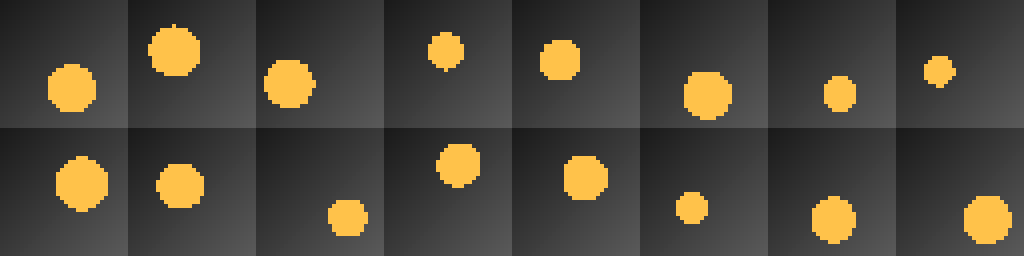

тестовые сцены 1–8: центр x, центр y, радиус (пиксели)
   20.0  13.5   6.7
   12.7  14.1   5.9
   22.4  21.9   4.9
   18.3   8.7   5.5
   17.8  12.0   5.8
   12.5  19.6   3.9
   15.8  22.5   5.7
   22.3  22.4   6.1


In [5]:
from PIL import Image
from IPython.display import display

Xtr, Xte, Ftr, Fte = L.dataset(KIND)
print("обучающая выборка:", tuple(Xtr.shape), " тестовая:", tuple(Xte.shape), " факторы:", tuple(Ftr.shape))
print(f"значения пикселей: {float(Xtr.min()):.2f}…{float(Xtr.max()):.2f}")


def make_sheet(rows, scale=4):
    """Лист из строк изображений (каждая строка — тензор n×3×32×32), увеличенный в scale раз."""
    grid = np.concatenate([np.concatenate(list(r.detach().permute(0, 2, 3, 1).cpu().numpy()), axis=1) for r in rows], axis=0)
    img = Image.fromarray((np.clip(grid, 0, 1) * 255).round().astype("uint8"))
    return img.resize((img.width * scale, img.height * scale), Image.NEAREST)


samples = make_sheet([Xtr[:8], Xte[:8]])
samples.save(ART / "samples.png")
display(samples)
px = L.N - 1
print("тестовые сцены 1–8: центр x, центр y, радиус (пиксели)")
for f in Fte[:8].cpu().numpy():
    print(f"  {(0.25 + 0.5 * f[0]) * px:5.1f} {(0.25 + 0.5 * f[1]) * px:5.1f} {(0.12 + 0.10 * f[2]) * px:5.1f}")

## 6. Эталон «средняя картинка» (шаг 5 плана)

Тривиальный «автокодировщик»: для любого входа выдаётся одно и то же изображение —
среднее по обучающей выборке. Он ничего не знает о конкретной сцене, поэтому PSNR
модели имеет смысл только как выигрыш над ним. Код взят из раздела 6.2 указаний. Набор
сцен тот же, что в демонстрационном варианте, а данные детерминированы, поэтому
значение должно совпасть с указаниями (17,171 дБ).

эталон «средняя картинка», PSNR на тесте: 17.171 дБ (в указаниях для набора «диск»: 17,171 дБ)


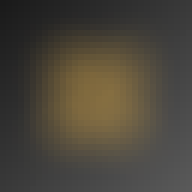

In [6]:
mean_image = Xtr.mean(0, keepdim=True).expand_as(Xte)
MEAN_PSNR = L.psnr_images(mean_image, Xte)
print(f"эталон «средняя картинка», PSNR на тесте: {MEAN_PSNR:.3f} дБ (в указаниях для набора «диск»: 17,171 дБ)")
display(make_sheet([Xtr.mean(0, keepdim=True)], scale=6))

## 7. Серия из пяти seed (шаг 4 плана)

`L.variant_summary(2)` сначала делает одно прогревочное обучение режима A с seed 0
(его метрики не используются), затем для каждого seed 101…105 обучает режимы A и B.
Каждое обучение — 20 эпох на 4096 сценах. Метрики считаются на 1024 тестовых сценах;
разрыв — PSNR на первых 1024 обучающих сценах минус PSNR на тестовых. В строке
таблицы: среднее A, выборочное стандартное отклонение s режима A, среднее B,
Δ = B − A, |Δ|/s и признак |Δ| > 2s. По числу параметров s = 0, поэтому признак 2s
для него неинформативен.

После серии печатается время на одно обучение и прогноз на оставшиеся
19 обучений.

In [7]:
t0 = time.perf_counter()
result = L.variant_summary(VARIANT)
T_SUMMARY = time.perf_counter() - t0
PER_RUN = T_SUMMARY / 11
ROWS = {r[0]: r for r in result["rows"]}

print(f"вариант {result['variant']}: набор {result['ctx']}, фактор {result['factor']}; seed {list(L.SEEDS)}")
print(f"{'метрика':24s} {'A':>9s} {'s':>7s} {'B':>9s} {'Δ':>9s} {'|Δ|/s':>7s}  |Δ|>2s")
for name, a, s, b, d, q, sig in result["rows"]:
    print(f"{NAMES[name]:24s} {a:9.3f} {s:7.3f} {b:9.3f} {d:+9.3f} {q:7.2f}  {'да' if sig else 'нет'}")
print(f"\nвыигрыш над эталоном «средняя картинка»: A {ROWS['psnr'][1] - MEAN_PSNR:+.2f} дБ, B {ROWS['psnr'][3] - MEAN_PSNR:+.2f} дБ")
print(f"серия: {T_SUMMARY:.0f} с на 11 обучений, ≈ {PER_RUN:.1f} с на одно; "
      f"оставшиеся 19 обучений ≈ {19 * PER_RUN / 60:.0f} мин")

вариант 2: набор 1, фактор latent_8_to_32; seed [101, 102, 103, 104, 105]
метрика                          A       s         B         Δ   |Δ|/s  |Δ|>2s
PSNR на тесте, дБ           26.047   0.553    27.209    +1.162    2.10  да
разрыв train−test, дБ        0.041   0.011     0.055    +0.014    1.30  нет
параметры, тыс.            101.035   0.000   150.211   +49.176     inf  да
время обучения, с            1.801   0.096     1.953    +0.152    1.59  нет

выигрыш над эталоном «средняя картинка»: A +8.88 дБ, B +10.04 дБ
серия: 28 с на 11 обучений, ≈ 2.6 с на одно; оставшиеся 19 обучений ≈ 1 мин


## 8. Классификация по допуску (шаг 7 плана)

Каждая метрика относится к одному из классов по допуску из раздела 4: «нейтрально»
(|Δ| в пределах допуска), «улучшение» или «ухудшение» (для параметров и времени
«ухудшение» означает рост затрат). Рядом стоит признак 2s. Строки, где критерий 2s и
допуск дают разный ответ, помечены: статистически заметное изменение может быть
практически неважным, и наоборот.

**Чувствительность вывода к допуску.** Для PSNR и разрыва классификация повторяется
при нескольких значениях допуска. Кроме того, печатается грубый интервал
Δ ± 2·SE, где SE ≈ s·√(2/5) — стандартная ошибка разности двух средних по пяти seed,
если разброс B такой же, как у A (`variant_summary` возвращает только s режима A).
Если интервал пересекает границу допуска, класс по этой метрике неустойчив: другая
серия seed может дать другой ответ.

In [8]:
def classify(metric, a, d, tol=None):
    kind, t = TOL[metric]
    t = t if tol is None else tol
    x = d if kind == "abs" else d / a
    if abs(x) <= t:
        return "нейтрально"
    return "улучшение" if (x > 0) == (BETTER[metric] > 0) else "ухудшение"


CLASSES = {}
print(f"{'метрика':24s} {'Δ':>9s} {'Δ, %':>8s} {'допуск':>9s}  {'класс':12s} |Δ|>2s  примечание")
for name, a, s, b, d, q, sig in result["rows"]:
    kind, t = TOL[name]
    cls = classify(name, a, d)
    CLASSES[name] = cls
    if name == "params":
        note = "s = 0: признак 2s неинформативен"
    elif sig != (cls != "нейтрально"):
        note = "критерий 2s и допуск расходятся"
    else:
        note = ""
    tol_txt = f"±{t:g}" if kind == "abs" else f"±{t:.0%}"
    print(f"{NAMES[name]:24s} {d:+9.3f} {100 * d / a:+7.1f}% {tol_txt:>9s}  {cls:12s} {'да' if sig else 'нет':6s} {note}")

print("\nчувствительность к допуску:")
SENS = {}
for name, tols in (("psnr", (0.25, 0.5, 1.0, 1.5, 2.0)), ("gap", (0.01, 0.02, 0.05, 0.1, 0.2))):
    _, a, s, b, d, q, sig = ROWS[name]
    se = s * (2 / 5) ** 0.5
    SENS[name] = {"se": se, "interval": [d - 2 * se, d + 2 * se], "by_tol": {str(t): classify(name, a, d, t) for t in tols}}
    print(f"  {NAMES[name]}: Δ = {d:+.3f}, грубый интервал Δ ± 2·SE = [{d - 2 * se:+.3f}; {d + 2 * se:+.3f}]")
    print("    " + "; ".join(f"допуск ±{t:g} → {classify(name, a, d, t)}" for t in tols))
    print(f"    класс меняется при допуске ±{abs(d):.3f}; "
          f"интервал {'пересекает' if (d - 2 * se) < TOL[name][1] < (d + 2 * se) or (d - 2 * se) < -TOL[name][1] < (d + 2 * se) else 'не пересекает'} "
          f"границу принятого допуска ±{TOL[name][1]:g}")

метрика                          Δ     Δ, %    допуск  класс        |Δ|>2s  примечание
PSNR на тесте, дБ           +1.162    +4.5%        ±1  улучшение    да     
разрыв train−test, дБ       +0.014   +34.1%      ±0.1  нейтрально   нет    
параметры, тыс.            +49.176   +48.7%      ±20%  ухудшение    да     s = 0: признак 2s неинформативен
время обучения, с           +0.152    +8.4%      ±20%  нейтрально   нет    

чувствительность к допуску:
  PSNR на тесте, дБ: Δ = +1.162, грубый интервал Δ ± 2·SE = [+0.463; +1.861]
    допуск ±0.25 → улучшение; допуск ±0.5 → улучшение; допуск ±1 → улучшение; допуск ±1.5 → нейтрально; допуск ±2 → нейтрально
    класс меняется при допуске ±1.162; интервал пересекает границу принятого допуска ±1
  разрыв train−test, дБ: Δ = +0.014, грубый интервал Δ ± 2·SE = [+0.000; +0.027]
    допуск ±0.01 → ухудшение; допуск ±0.02 → нейтрально; допуск ±0.05 → нейтрально; допуск ±0.1 → нейтрально; допуск ±0.2 → нейтрально
    класс меняется при допуске ±0.014; и

## 9. Диагностика по размеру латентного вектора (шаг 8 плана)

Повторяю диагностику демонстрационного варианта для своего набора: PSNR на тесте при
`d = 1, 2, 3, 4, 8` по seed 101–103. Набор тот же, что в демонстрационном варианте,
поэтому строки сопоставляются с таблицей раздела 6.4 указаний (Colab GPU). Это и есть
проверка воспроизведения демонстрационного варианта. Для своего фактора
добавляю `d = 32`.

Ожидание по механизму: рост до `d = 3` (по числу факторов сцены) и плато дальше; при
`d < 3` информация теряется по построению.

Обученные модели сохраняются в словаре `MODELS`. Конфигурации `d = 8` и `d = 32` с
seed 101 совпадают с режимами A и B, поэтому лист сравнения (раздел 10) строится из
этих же моделей, без повторного обучения.

In [9]:
SWEEP_D = (1, 2, 3, 4, 8, 32)
SWEEP_SEEDS = (101, 102, 103)
DEMO_SWEEP = {1: 20.64, 2: 23.16, 3: 25.24, 4: 26.45, 8: 25.70}   # раздел 6.4 указаний, Colab GPU T4
MODELS, SWEEP = {}, {}
t0 = time.perf_counter()
for d in SWEEP_D:
    vals = []
    for s in SWEEP_SEEDS:
        metrics, model = L.run(KIND, dict(L.BASE, d=d), s)
        MODELS[(d, s)] = (metrics, model)
        vals.append(metrics["psnr"])
    SWEEP[d] = vals
    demo = f"{DEMO_SWEEP[d]:.2f}" if d in DEMO_SWEEP else "—"
    print(f"d={d:2d}: PSNR = {np.mean(vals):.2f} дБ (по seed: {', '.join(f'{v:.2f}' for v in vals)}); "
          f"над эталоном {np.mean(vals) - MEAN_PSNR:+.2f} дБ; в указаниях: {demo}")
T_SWEEP = time.perf_counter() - t0
print(f"развёртка: {T_SWEEP:.0f} с на {len(SWEEP_D) * len(SWEEP_SEEDS)} обучений")

d= 1: PSNR = 20.69 дБ (по seed: 20.66, 20.81, 20.61); над эталоном +3.52 дБ; в указаниях: 20.64
d= 2: PSNR = 23.18 дБ (по seed: 23.31, 23.44, 22.78); над эталоном +6.01 дБ; в указаниях: 23.16
d= 3: PSNR = 25.29 дБ (по seed: 24.82, 24.79, 26.25); над эталоном +8.12 дБ; в указаниях: 25.24
d= 4: PSNR = 26.38 дБ (по seed: 26.79, 26.16, 26.17); над эталоном +9.20 дБ; в указаниях: 26.45
d= 8: PSNR = 25.89 дБ (по seed: 26.03, 26.59, 25.06); над эталоном +8.72 дБ; в указаниях: 25.70
d=32: PSNR = 26.71 дБ (по seed: 27.02, 26.30, 26.82); над эталоном +9.54 дБ; в указаниях: —
развёртка: 33 с на 18 обучений


## 10. Лист сравнения `comparison.png` (шаг 6 плана)

Строки листа: «оригинал», «режим A (`d = 8`)», «режим B (`d = 32`)». Это первые 8
тестовых сцен, модели обучены с seed 101; построение повторяет код раздела 6.2
указаний. Модели берутся из развёртки: конфигурация и seed те же, что у режимов A и
B. На GPU повторное обучение с тем же seed может дать результат, отличающийся в
пределах разброса между seed; насколько — проверяется в разделе 12. Под листом печатается
PSNR каждой из восьми сцен для обоих режимов. По листу оцениваю глазами, остаётся ли
диск круглым и восстанавливаются ли положение и размер без смещения.

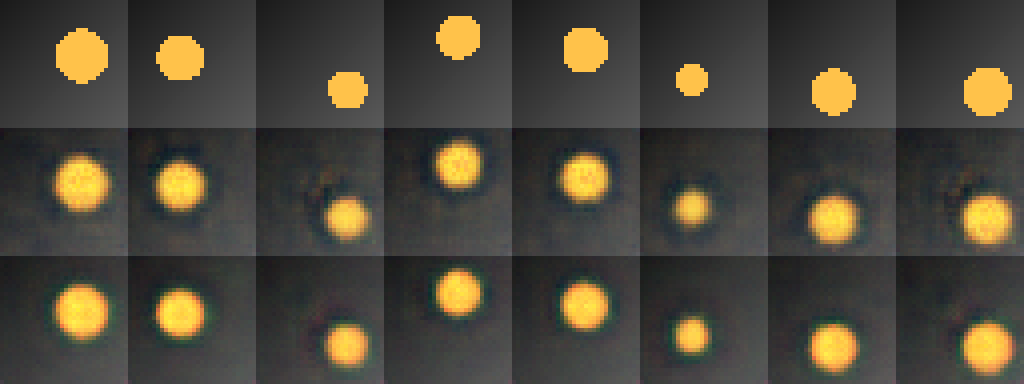

строки: оригинал / режим A (d = 8) / режим B (d = 32); seed 101
PSNR по сценам, A: 25.50 26.10 26.64 25.94 26.09 27.03 26.14 26.42
PSNR по сценам, B: 25.89 26.63 27.51 27.05 27.11 28.34 27.03 26.85


In [10]:
assert a_cfg == dict(L.BASE, d=8) and b_cfg == dict(L.BASE, d=32)
model_a, model_b = MODELS[(8, 101)][1], MODELS[(32, 101)][1]
rec_a = L.reconstruct(model_a, Xte[:8], a_cfg["eval_noise"])
rec_b = L.reconstruct(model_b, Xte[:8], b_cfg["eval_noise"])
sheet = make_sheet([Xte[:8], rec_a, rec_b])
sheet.save(ART / "comparison.png")
display(sheet)


def psnr_each(x, y):
    mse = ((x - y) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return (10 * torch.log10(1.0 / mse)).cpu().numpy()


print("строки: оригинал / режим A (d = 8) / режим B (d = 32); seed 101")
print("PSNR по сценам, A:", " ".join(f"{v:5.2f}" for v in psnr_each(rec_a, Xte[:8])))
print("PSNR по сценам, B:", " ".join(f"{v:5.2f}" for v in psnr_each(rec_b, Xte[:8])))

## 11. Форма и положение диска на всей тестовой выборке

Вариант требует оценить глазами, что диск остаётся круглым, а положение и размер
восстанавливаются без смещения. Восемь сцен листа — малая выборка, поэтому ту же
проверку делаю численно на всех 1024 тестовых сценах для моделей seed 101.

Маска диска — пиксели, у которых красный канал больше 0,675: у диска он равен 1,0, у
фона не выше 0,35, порог — середина. По маске считаются центр (среднее координат),
эквивалентный радиус √(площадь/π) и округлость √(λ_min/λ_max) по собственным числам
ковариации координат (у круга 1). Та же оценка на оригиналах — опорная: разность
«реконструкция − оригинал» показывает смещение, внесённое автокодировщиком, а не
погрешность оценки. Для контроля печатается и ошибка оценки на оригиналах
относительно истинных факторов сцены.

Критерий записан до запуска: среднее смещение центра и радиуса по модулю меньше
0,5 пикселя, средняя абсолютная ошибка меньше 1 пикселя, округлость больше 0,9.

In [11]:
_yy, _xx = torch.meshgrid(torch.arange(L.N, dtype=torch.float32), torch.arange(L.N, dtype=torch.float32), indexing="ij")
_yy, _xx = _yy.to(L.DEVICE), _xx.to(L.DEVICE)


def disc_geometry(X, thr=0.675):
    """Центр, эквивалентный радиус и округлость маски диска (пиксели) для каждой сцены."""
    m = (X[:, 0] > thr).float()
    area = m.sum((1, 2))
    a = area.clamp_min(1)
    cx, cy = (m * _xx).sum((1, 2)) / a, (m * _yy).sum((1, 2)) / a
    dx, dy = _xx - cx[:, None, None], _yy - cy[:, None, None]
    vxx, vyy, vxy = (m * dx * dx).sum((1, 2)) / a, (m * dy * dy).sum((1, 2)) / a, (m * dx * dy).sum((1, 2)) / a
    half, root = (vxx + vyy) / 2, torch.sqrt(((vxx - vyy) / 2) ** 2 + vxy ** 2)
    roundness = torch.sqrt((half - root).clamp_min(0) / (half + root).clamp_min(1e-9))
    return {"cx": cx, "cy": cy, "r": torch.sqrt(area / np.pi), "round": roundness, "empty": int((area == 0).sum())}


g_orig = disc_geometry(Xte)
truth = {"cx": (0.25 + 0.5 * Fte[:, 0]) * px, "cy": (0.25 + 0.5 * Fte[:, 1]) * px, "r": (0.12 + 0.10 * Fte[:, 2]) * px}
print("оценка на оригиналах относительно истинных факторов (погрешность самой оценки), пиксели:")
print("  " + "; ".join(f"{q}: смещение {float((g_orig[q] - truth[q]).mean()):+.3f}, ср. abs {float((g_orig[q] - truth[q]).abs().mean()):.3f}" for q in truth))
print(f"  округлость оригиналов: {float(g_orig['round'].mean()):.3f}")

GEOMETRY = {}
for mode, model in (("A", model_a), ("B", model_b)):
    g = disc_geometry(L.reconstruct(model, Xte))
    row = {q: {"bias": float((g[q] - g_orig[q]).mean()), "mae": float((g[q] - g_orig[q]).abs().mean())} for q in ("cx", "cy", "r")}
    row["roundness"] = float(g["round"].mean())
    row["roundness_min"] = float(g["round"].min())
    row["empty_masks"] = g["empty"]
    passed = all(abs(row[q]["bias"]) < 0.5 and row[q]["mae"] < 1.0 for q in ("cx", "cy", "r")) and row["roundness"] > 0.9 and g["empty"] == 0
    row["criterion_met"] = passed
    GEOMETRY[mode] = row
    print(f"режим {mode}: " + "; ".join(f"{q}: смещение {row[q]['bias']:+.3f}, ср. abs {row[q]['mae']:.3f}" for q in ("cx", "cy", "r"))
          + f"; округлость {row['roundness']:.3f} (мин. {row['roundness_min']:.3f}); пустых масок {row['empty_masks']}"
          + f" → критерий {'выполнен' if passed else 'НЕ выполнен'}")

оценка на оригиналах относительно истинных факторов (погрешность самой оценки), пиксели:
  cx: смещение +0.003, ср. abs 0.051; cy: смещение +0.001, ср. abs 0.051; r: смещение +0.001, ср. abs 0.038
  округлость оригиналов: 0.969
режим A: cx: смещение +0.006, ср. abs 0.086; cy: смещение +0.004, ср. abs 0.087; r: смещение -0.154, ср. abs 0.156; округлость 0.953 (мин. 0.834); пустых масок 0 → критерий выполнен
режим B: cx: смещение +0.031, ср. abs 0.071; cy: смещение +0.016, ср. abs 0.066; r: смещение -0.052, ср. abs 0.068; округлость 0.960 (мин. 0.831); пустых масок 0 → критерий выполнен


## 12. Воспроизводимость: повторный запуск и сверка с прогоном преподавателя

Две проверки.

1. **Повторный запуск.** Режим A с seed 101 обучается ещё раз, и PSNR
   сравнивается с моделью из развёртки. На GPU обучение не побитово детерминировано:
   указания фиксируют, что два запуска одного варианта на Colab дали 26,13 и 26,00 дБ.
   Поэтому ожидается совпадение либо до бита, либо расхождение в пределах разброса s
   режима A из раздела 7. Ячейка печатает, какой из случаев наблюдается; расхождение в
   пределах s ошибкой не считается. На CPU (запасной путь) ожидается совпадение до бита.
2. **Сверка с прогоном преподавателя.** В выданных материалах
   (`assignment/demo_journal/results_30_variants.json`) есть строка варианта 2,
   полученная на Colab GPU T4. Числа перенесены в ячейку вручную. Данные и начальные веса у прогона преподавателя и
   этого прогона одинаковые: веса
   инициализируются на CPU до переноса на устройство. Расходятся только округления
   на разных GPU (и порядок операций в недетерминированных ядрах), поэтому средние
   должны совпасть в пределах разброса s, но не до знака. Время обучения на разных
   устройствах сравнивается с осторожностью; классифицируется только его
   относительное изменение A → B внутри одной машины.

In [12]:
m_again, _ = L.run(KIND, a_cfg, 101)
m_first = MODELS[(8, 101)][0]
DETERMINISTIC = m_again["psnr"] == m_first["psnr"]
RERUN_DIFF = m_again["psnr"] - m_first["psnr"]
RERUN_WITHIN_S = abs(RERUN_DIFF) <= ROWS["psnr"][2]
verdict = ("совпадают до бита" if DETERMINISTIC else
           f"расхождение {RERUN_DIFF:+.3f} дБ, в пределах s = {ROWS['psnr'][2]:.3f} дБ: {'да' if RERUN_WITHIN_S else 'нет'}")
print(f"режим A, seed 101 ({L.DEVICE}): развёртка {m_first['psnr']:.6f} дБ, повтор {m_again['psnr']:.6f} дБ → {verdict}")

# results_30_variants.json преподавателя, вариант 2 (Colab, GPU T4): A, s, B, Δ
COLAB_V2 = {"psnr": (26.1448, 0.7148, 27.209, 1.0642), "gap": (0.0424, 0.0081, 0.0533, 0.0109),
            "params": (101.035, 0.0, 150.211, 49.176), "seconds": (2.1389, 0.1837, 2.1743, 0.0354)}
COLAB_MEAN_PSNR = 17.171   # раздел 6.4 указаний
print(f"\nэталон «средняя картинка»: здесь {MEAN_PSNR:.3f} дБ, указания {COLAB_MEAN_PSNR:.3f} дБ, разность {MEAN_PSNR - COLAB_MEAN_PSNR:+.4f}")
print(f"\n{'метрика':24s} {'A здесь':>9s} {'A Colab':>9s} {'B здесь':>9s} {'B Colab':>9s} {'Δ здесь':>9s} {'Δ Colab':>9s}  ΔA/s  ΔB/s  класс Colab по допуску")
REPRO = {}
for name, a, s, b, d, q, sig in result["rows"]:
    ca, cs, cb, cd = COLAB_V2[name]
    if name == "seconds":
        da = db = float("nan")
    else:
        da = (a - ca) / cs if cs > 0 else (0.0 if abs(a - ca) < 1e-3 else float("inf"))
        db = (b - cb) / cs if cs > 0 else (0.0 if abs(b - cb) < 1e-3 else float("inf"))
    REPRO[name] = {"this_run": [a, s, b, d], "colab": [ca, cs, cb, cd], "dA_over_s_colab": da, "dB_over_s_colab": db,
                   "class_this_run": classify(name, a, d), "class_colab": classify(name, ca, cd)}
    print(f"{NAMES[name]:24s} {a:9.3f} {ca:9.3f} {b:9.3f} {cb:9.3f} {d:+9.3f} {cd:+9.3f} {da:+5.2f} {db:+5.2f}  "
          f"{REPRO[name]['class_colab']} (здесь: {REPRO[name]['class_this_run']})")
print("\nΔA/s, ΔB/s — отличие средних этого прогона от Colab в единицах разброса s Colab; для времени не считается (разные устройства).")

print("\nразвёртка по d, этот прогон против указаний (seed 101–103):")
for d, vals in SWEEP.items():
    if d in DEMO_SWEEP:
        print(f"  d={d:2d}: здесь {np.mean(vals):.2f} дБ, указания {DEMO_SWEEP[d]:.2f} дБ, разность {np.mean(vals) - DEMO_SWEEP[d]:+.2f}")

режим A, seed 101 (cuda): развёртка 26.033554 дБ, повтор 25.668451 дБ → расхождение -0.365 дБ, в пределах s = 0.553 дБ: да

эталон «средняя картинка»: здесь 17.171 дБ, указания 17.171 дБ, разность -0.0003

метрика                    A здесь   A Colab   B здесь   B Colab   Δ здесь   Δ Colab  ΔA/s  ΔB/s  класс Colab по допуску
PSNR на тесте, дБ           26.047    26.145    27.209    27.209    +1.162    +1.064 -0.14 -0.00  улучшение (здесь: улучшение)
разрыв train−test, дБ        0.041     0.042     0.055     0.053    +0.014    +0.011 -0.19 +0.18  нейтрально (здесь: нейтрально)
параметры, тыс.            101.035   101.035   150.211   150.211   +49.176   +49.176 +0.00 +0.00  ухудшение (здесь: ухудшение)
время обучения, с            1.801     2.139     1.953     2.174    +0.152    +0.035  +nan  +nan  нейтрально (здесь: нейтрально)

ΔA/s, ΔB/s — отличие средних этого прогона от Colab в единицах разброса s Colab; для времени не считается (разные устройства).

развёртка по d, этот прогон прот

## 13. Сохранение результатов

Все числа сохраняются в `artifacts/results.json`: среда, контрольная сумма
библиотеки, режимы, таблица серии, эталон, классификация, чувствительность,
развёртка по `d`, геометрия диска, сверка с Colab и время шагов. Затем печатаются
SHA-256 всех файлов в `artifacts/`, чтобы перенесённые в репозиторий копии можно было сверить
с выводом этой ячейки.

In [13]:
import json


def finite(x):
    return x if isinstance(x, (int, float)) and np.isfinite(x) else None


T_TOTAL = time.perf_counter() - T_START
results = {
    "lab": "ЛР 7. Построение автокодировщика",
    "student": "Яковенко Максим Михайлович",
    "variant": VARIANT, "kind": KIND, "factor": FACTOR,
    "mode_a": a_cfg, "mode_b": b_cfg, "seeds": list(L.SEEDS), "data_seed": 7,
    "environment": ENV, "device": L.DEVICE,
    "lab07_lib": {"bytes": len(lib_bytes), "sha256": LIB_SHA},
    "tolerance": {m: {"type": t[0], "value": t[1]} for m, t in TOL.items()},
    "summary": [{"metric": n, "A": a, "s": s, "B": b, "delta": d, "abs_delta_over_s": finite(q), "gt_2s": sig,
                 "class": CLASSES[n]} for n, a, s, b, d, q, sig in result["rows"]],
    "mean_image_psnr": MEAN_PSNR,
    "gain_over_mean_image": {"A": ROWS["psnr"][1] - MEAN_PSNR, "B": ROWS["psnr"][3] - MEAN_PSNR},
    "sensitivity": SENS,
    "latent_sweep": {"seeds": list(SWEEP_SEEDS), "psnr": {str(d): v for d, v in SWEEP.items()},
                     "mean": {str(d): float(np.mean(v)) for d, v in SWEEP.items()}},
    "disc_geometry_seed101": GEOMETRY,
    "reproducibility": {"rerun_identical": DETERMINISTIC, "rerun_diff_db": RERUN_DIFF, "rerun_within_s": RERUN_WITHIN_S, "rerun_psnr": m_again["psnr"], "first_psnr": m_first["psnr"],
                        "colab_v2": {k: {kk: (finite(vv) if isinstance(vv, float) else vv) for kk, vv in v.items()} for k, v in REPRO.items()}},
    "timing_s": {"summary_11_runs": T_SUMMARY, "per_run": PER_RUN, "sweep_runs": T_SWEEP, "total_notebook": T_TOTAL},
}
(ART / "results.json").write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"время выполнения блокнота: {T_TOTAL / 60:.1f} мин")
print("SHA-256 артефактов:")
for p in sorted(ART.iterdir()):
    if p.is_file():
        print(f"  {hashlib.sha256(p.read_bytes()).hexdigest()}  {p.stat().st_size:8d}  {p.name}")
print(f"  {LIB_SHA}  {len(lib_bytes):8d}  lab07_lib.py")

время выполнения блокнота: 2.4 мин
SHA-256 артефактов:
  254a63debe73acec8d9166937fd9a71a941abdbd62ca6cae9b4d5a1dcc83271b     49786  comparison.png
  32fdda93a3b52ae1de7811862c2920974a89ca262a45c65fd3f2dff76a4b641f      7412  results.json
  00b02936ebc67376c9efb19c6196c7db26df19204ffc8c62b3732ed0916efa4b      4659  samples.png
  d84b83a878f55e95289d76a788dc9fa84d3249d0d33aa719d9db8d6792fd2698      8679  lab07_lib.py


## 13а. Демонстрационный скрипт преподавателя

Скрипт демонстрационного варианта преподавателя `lab07_demo.py` (вариант 1: набор «диск» × латент 8 → 2, эталон «средняя картинка», диагностика по `d`, лист сравнения) выполняется без изменений. Файл записывается ячейкой `%%writefile` (текст побайтно совпадает с выданным) и запускается в подпапке `demo/`, чтобы его `comparison.png` не перезаписал лист сравнения варианта. Его числа сопоставляются с разделом 6 указаний. После запуска его таблица сравнивается со строкой варианта 1 из `results_30_variants.json` преподавателя: числа должны совпасть в пределах разброса s, а знак Δ и признак 2s — полностью. Время сравнивается только по смыслу (другая машина).


In [14]:
%%writefile lab07_demo.py
# ЛР 7. Демонстрационный вариант 1: набор «диск», фактор «размер латентного вектора 8 → 2».
import numpy as np
import lab07_lib as L

N = 1
c, k = (N - 1) // 6, (N - 1) % 6
a_cfg, b_cfg = L.settings(L.FACTORS[k])
print("A:", a_cfg)
print("B:", b_cfg)

# Серия из пяти seed: метрики режимов A и B
result = L.variant_summary(N)
for name, a, s, b, d, q, sig in result["rows"]:
    print(f"{name:8s} A={a:8.3f} s={s:6.3f} B={b:8.3f} d={d:+8.3f} |d|/s={q:7.2f} 2s={'да' if sig else 'нет'}")

# Тривиальный эталон: средняя картинка обучающей выборки, одинаковая для всех входов
Xtr, Xte, Ftr, Fte = L.dataset(L.KINDS[c])
mean_image = Xtr.mean(0, keepdim=True).expand_as(Xte)
print("эталон «средняя картинка», PSNR на тесте:", round(L.psnr_images(mean_image, Xte), 3))

# Диагностика: PSNR в зависимости от размера латентного вектора (seed 101, 102, 103)
for d in (1, 2, 3, 4, 8):
    vals = [L.run(L.KINDS[c], dict(L.BASE, d=d), s)[0]["psnr"] for s in (101, 102, 103)]
    print(f"d={d}: PSNR = {np.mean(vals):.2f} дБ (по seed: {', '.join(f'{v:.2f}' for v in vals)})")

# Лист сравнения comparison.png: оригиналы, реконструкции режима A и режима B (seed 101, первые 8 тестовых сцен)
from PIL import Image
rows = [Xte[:8]]
for cfg in (a_cfg, b_cfg):
    model = L.run(L.KINDS[c], cfg, 101)[1]
    rows.append(L.reconstruct(model, Xte[:8], cfg["eval_noise"]))
grid = np.concatenate([np.concatenate(list(r.permute(0, 2, 3, 1).cpu().numpy()), axis=1) for r in rows], axis=0)
sheet = Image.fromarray((grid * 255).round().astype("uint8")).resize((8 * 32 * 4, 3 * 32 * 4), Image.NEAREST)
sheet.save("comparison.png")
sheet


Writing lab07_demo.py


In [15]:
import runpy
DEMO = WORK / "demo"
DEMO.mkdir(exist_ok=True)
os.chdir(DEMO)   # скрипт пишет comparison.png по относительному пути — отдельная папка, чтобы не перезаписать лист варианта
try:
    demo_globals = runpy.run_path(str(WORK / "lab07_demo.py"), run_name="__main__")
finally:
    os.chdir(WORK)

# Сверка с прогоном преподавателя: results_30_variants.json, вариант 1 (Colab, GPU T4): A, s, B, Δ
COLAB_V1 = {"psnr": (26.1262, 0.6511, 23.1971, -2.9291), "gap": (0.0411, 0.0090, 0.0992, 0.0581),
            "params": (101.035, 0.0, 88.741, -12.294), "seconds": (2.1143, 0.0877, 2.3265, 0.2122)}
print(f"\n{'метрика':10s} {'A здесь':>9s} {'A указ.':>9s} {'B здесь':>9s} {'B указ.':>9s} {'Δ здесь':>9s} {'Δ указ.':>9s}  2s здесь/указ.")
DEMO_V1 = {}
for name, a, s, b, d, q, sig in demo_globals["result"]["rows"]:
    ca, cs, cb, cd = COLAB_V1[name]
    DEMO_V1[name] = {"this_run": [a, s, b, d, bool(sig)], "colab": [ca, cs, cb, cd, abs(cd) > 2 * cs]}
    print(f"{name:10s} {a:9.3f} {ca:9.3f} {b:9.3f} {cb:9.3f} {d:+9.3f} {cd:+9.3f}  "
          f"{'да' if sig else 'нет'}/{'да' if abs(cd) > 2 * cs else 'нет'}")
same = all(v["this_run"][4] == v["colab"][4] and (v["this_run"][3] > 0) == (v["colab"][3] > 0)
           for k, v in DEMO_V1.items() if k != "seconds")
print("Демонстрационный вариант: знак Δ и признак 2s по PSNR, разрыву и параметрам совпали с указаниями:", same)


A: {'arch': 'conv', 'd': 8, 'loss': 'mse', 'noise': 0.0, 'eval_noise': 0.0, 'n_train': 4096, 'epochs': 20}
B: {'arch': 'conv', 'd': 2, 'loss': 'mse', 'noise': 0.0, 'eval_noise': 0.0, 'n_train': 4096, 'epochs': 20}
psnr     A=  25.916 s= 0.738 B=  23.220 d=  -2.696 |d|/s=   3.65 2s=да
gap      A=   0.043 s= 0.010 B=   0.100 d=  +0.058 |d|/s=   6.03 2s=да
params   A= 101.035 s= 0.000 B=  88.741 d= -12.294 |d|/s=    inf 2s=да
seconds  A=   1.891 s= 0.258 B=   1.829 d=  -0.062 |d|/s=   0.24 2s=нет
эталон «средняя картинка», PSNR на тесте: 17.171
d=1: PSNR = 20.64 дБ (по seed: 20.66, 20.75, 20.52)
d=2: PSNR = 23.16 дБ (по seed: 23.28, 23.43, 22.77)
d=3: PSNR = 25.22 дБ (по seed: 24.58, 24.81, 26.27)
d=4: PSNR = 26.31 дБ (по seed: 26.93, 25.87, 26.12)
d=8: PSNR = 25.79 дБ (по seed: 25.80, 26.51, 25.07)

метрика      A здесь   A указ.   B здесь   B указ.   Δ здесь   Δ указ.  2s здесь/указ.
psnr          25.916    26.126    23.220    23.197    -2.696    -2.929  да/да
gap            0.043     0

## 14. Вывод

**Наблюдение.** Серия seed 101…105, оценка на 1024 тестовых сценах, Google Colab, Tesla T4:

| Метрика | A (`d = 8`) | s | B (`d = 32`) | Δ | \|Δ\|/s | \|Δ\| > 2s | допуск | класс по допуску |
| --- | ---: | ---: | ---: | ---: | ---: | :---: | :---: | --- |
| PSNR на тесте, дБ | 26,047 | 0,553 | 27,209 | +1,162 | 2,10 | да | ±1,0 дБ | улучшение |
| разрыв train − test, дБ | 0,041 | 0,011 | 0,055 | +0,014 | 1,30 | нет | ±0,1 дБ | нейтрально |
| параметры, тыс. | 101,035 | 0 | 150,211 | +49,176 (+48,7 %) | — | да (s = 0, неинформативно) | ±20 % | ухудшение (рост затрат) |
| время обучения, с | 1,801 | 0,096 | 1,953 | +0,152 (+8,4 %) | 1,59 | нет | ±20 % | нейтрально |

* Эталон «средняя картинка» — 17,171 дБ, совпал с указаниями. Выигрыш над ним: A +8,88 дБ,
  B +10,04 дБ. Оба режима восстанавливают сцену, а не выдают «среднее».
* **PSNR:** +1,16 дБ — больше 2s (|Δ|/s = 2,10) и больше допуска, но превышение допуска всего
  0,16 дБ. Грубый интервал Δ ± 2·SE = [+0,46; +1,86] дБ пересекает границу ±1,0; при допуске
  ±1,5 дБ класс был бы «нейтрально». **Знак** эффекта устойчив: B лучше A на всех 8 сценах листа
  сравнения, в прогоне преподавателя Δ = +1,06 дБ. **Класс** «улучшение» неустойчив.
* **Разрыв train − test** вырос на 0,014 дБ, в 7 раз меньше допуска. Переобучения нет ни в одном
  режиме.
* **Цена:** +49 176 весов (+48,7 %), ровно столько, сколько вычислено до запуска; время обучения
  в пределах допуска.
* **Форма и положение диска** (требование варианта): на листе сравнения диск круглый, положение и
  размер совпадают с оригиналом. Численно, по всем 1024 тестовым сценам: среднее смещение центра не
  больше 0,031 пикселя, округлость 0,953 (A) и 0,960 (B), критерий выполнен в обоих режимах. Радиус в
  режиме A систематически меньше на 0,15 пикселя, в режиме B — на 0,05 пикселя.
* **Диагностика по `d`** (seed 101–103): 20,69 → 23,18 → 25,29 → 26,38 (`d = 4`) → 25,89 (`d = 8`) →
  26,71 (`d = 32`) дБ. Рост до `d = 3–4`, дальше изменения порядка разброса между seed.
  Демонстрационная развёртка указаний воспроизведена с разностью не больше 0,19 дБ.

**Сопоставление с гипотезой** (журнал, коммит `c5deb11`). Подтвердились предсказания по числу
параметров, разрыву и времени. По PSNR гипотеза **опровергнута** по критерию, записанному до
запуска («Δ PSNR > +1,0 дБ»): ожидалось около +0,5 дБ и «нейтрально», получено +1,16 дБ и
«улучшение». Не сбылось и предсказание «по PSNR |Δ| > 2s — нет».

**Объяснение** (предположение о причине, а не наблюдение). Новой информации о сцене в 24
добавленных координатах нет: сцена задаётся тремя числами, разрыв не вырос, развёртка выходит на
плато при `d = 3–4`. Вероятная причина выигрыша — декодировщик. Его первый слой `Linear(d, 1024)`
строит карту признаков 64 × 4 × 4, и до ReLU она лежит в подпространстве размерности не больше `d`.
При `d = 32` декодировщику проще за те же 640 шагов построить резкий край диска. С этим согласуются
два наблюдения: занижение радиуса уменьшилось втрое (0,15 → 0,05 пикселя), а на листе сравнения у B
тоньше тёмный ореол вокруг диска. Отличить «выразительность декодировщика» от «скорости
сходимости» эта серия не позволяет: для этого нужен прогон с большим числом эпох (раздел 15).

**Ответ на вопрос варианта.** Рост узкого места с 8 до 32 чисел даёт небольшой выигрыш качества
на границе допуска (+1,16 дБ). Переобучение и время обучения при этом не растут, а число
параметров растёт на 48,7 %. По допуску, записанному до запуска, это компромисс «качество за
ёмкость», а не бесплатный выигрыш. Если ограничен размер модели, превышение допуска на 0,16 дБ не
оправдывает почти полуторного роста числа весов. Если ограничено время, рост `d` окупается: время в
допуске. Вывод относится только к набору «диск», свёрточной архитектуре и бюджету 20 эпох.

## 15. Ограничения

* **Один синтетический набор.** Три фактора сцены, гладкий фон без шума, изображения 32 × 32.
  Перенос вывода на фотографии и на наборы с большим числом факторов не проверялся.
* **Одна архитектура и один бюджет обучения** (свёрточная сеть, 20 эпох = 640 шагов). При более
  долгом обучении выигрыш `d = 32` может исчезнуть, если причина — скорость сходимости, или
  сохраниться, если причина — выразительность декодировщика. Этот прогон не выполнялся.
* **Пять seed и s только по режиму A.** При n = 5 оценка s грубая: здесь s по PSNR 0,553 дБ, в
  прогоне преподавателя 0,715 дБ. Поэтому признак 2s по PSNR здесь «да» (2,10), а там «нет» (1,49).
  Стандартная ошибка разности оценена в предположении, что у B такой же разброс, как у A.
* **Пары A–B по seed связаны лишь частично.** При одном seed свёртки кодировщика получают одинаковые
  начальные веса. Слои после `Linear(1024, d)` получают другие случайные числа, потому что весов в
  нём разное число.
* **GPU не детерминирован.** Повторное обучение A с seed 101 дало −0,365 дБ (в пределах s).
  Лист сравнения и геометрия построены по моделям развёртки (та же конфигурация, seed 101), а они
  совпадают с моделями серии только с этой точностью.
* **Ограничения метрик.** PSNR усредняет ошибку по пикселям: он не отличает размытие края от сдвига
  диска и не говорит, где находится ошибка (край, фон, ореол). Геометрия измерена по порогу 0,675
  красного канала. Размытие выпуклого края сдвигает этот порог внутрь, поэтому занижение радиуса
  отражает и размытие, а не только уменьшение диска.
* **Время** измерено на общей машине Colab. Сравнивается только относительное изменение A → B
  внутри одного сеанса; абсолютные секунды на другом GPU будут другими.
* **Гипотеза не полностью «слепая».** Строка варианта 2 из прогона преподавателя была видна до
  запуска; это записано в журнале. Допуски взяты из образца без изменений. По PSNR гипотеза
  противоречила этой строке и не сбылась, то есть подгонки под известный ответ не было.

## 16. Паспорт эксперимента

| Поле | Значение |
| --- | --- |
| Работа, вариант | ЛР №7 «Построение автокодировщика», вариант 2: набор 1 «диск» (`disc`) × фактор 2 «размер латентного вектора 8 → 32» (`latent_8_to_32`) |
| Исполнитель | Яковенко Максим Михайлович, Т26ИИКТ-МИК11 |
| Данные | синтетические, `L.dataset("disc")`, seed данных 7; 4096 обучающих и 1024 тестовые сцены 3 × 32 × 32, значения 0,10…1,00; внешних файлов и персональных данных нет |
| Серия seed | 101…105 (обучение; прогрев с seed 0 не учитывается); развёртка по `d` — seed 101–103 |
| Режим A | `conv`, `d = 8`, MSE, `noise = 0`, `eval_noise = 0`, `n_train = 4096`, 20 эпох; Adam, шаг 2·10⁻³, пакет 128 |
| Режим B | то же, `d = 32` — единственное различие (проверено `assert`) |
| Метрики | PSNR на 1024 тестовых сценах; разрыв train − test (1024 обучающие минус 1024 тестовые); параметры, тыс.; время 20 эпох, с; дополнительно — центр, радиус и округлость диска на 1024 тестовых сценах |
| Допуск (до запуска, коммит `c5deb11`) | PSNR ±1,0 дБ; разрыв ±0,1 дБ; время ±20 %; параметры ±20 % |
| Эталон | «средняя картинка» обучающей выборки: 17,171 дБ (в указаниях 17,171 дБ) |
| Среда | Google Colab, GPU Tesla T4, CUDA 13.0; Python 3.13.15; torch 2.11.0+cu130; numpy 2.1.3; Pillow 11.3.0; Linux 6.6.122+ (glibc 2.39); Intel Xeon 2,00 ГГц, 2 ядра, ОЗУ 12,7 ГБ |
| Библиотека | `lab07_lib.py` из приложения А, 8679 байт, SHA-256 `d84b83a878f55e95289d76a788dc9fa84d3249d0d33aa719d9db8d6792fd2698` (совпадает с указаниями) |
| Детерминизм | на GPU не побитовый: повтор A, seed 101 — 26,034 и 25,668 дБ (−0,365 дБ, в пределах s = 0,553 дБ) |
| Время выполнения | серия (11 обучений) 28 с, ≈ 2,6 с на обучение с оценкой; развёртка (18 обучений) 33 с; весь блокнот 2,4 мин |
| Результаты | A 26,047 дБ, B 27,209 дБ, Δ = +1,162 дБ (\|Δ\|/s = 2,10) — «улучшение»; разрыв +0,014 дБ — «нейтрально»; параметры +48,7 % — «ухудшение»; время +8,4 % — «нейтрально» |
| Артефакты, SHA-256 | `comparison.png` `254a63debe73acec8d9166937fd9a71a941abdbd62ca6cae9b4d5a1dcc83271b`; `samples.png` `00b02936ebc67376c9efb19c6196c7db26df19204ffc8c62b3732ed0916efa4b`; `results.json` `32fdda93a3b52ae1de7811862c2920974a89ca262a45c65fd3f2dff76a4b641f` |
| Повторение | выполнить блокнот сверху вниз в Colab с GPU T4; средние должны совпасть в пределах s, эталон и параметры — точно |
| Репозиторий | https://github.com/ykvnkm/ai-in-creative-industries/tree/main/LR07 |